In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Approximate the indtencity distribution by a function $$ a1+a2*x+a3*x^2 + b1*cos(c1+c2*x) $$
# using scipy function "curve_fit" for determination of coefficients


# Koeffitient "c2" is the frequency of the signal we need to find.

In [17]:
from scipy.optimize import curve_fit

In [47]:
def func(x, a1,a2,a3,b1,c1,c2):
    return a1+a2*x+a3*x**2 + b1*np.cos(c1+c2*x)

In [48]:
popt, pcov = curve_fit(func, dist, line)
print(popt)

[ 8.48506958e+01  6.46410846e-01 -7.35757568e-03  6.19203843e+00
 -1.47434716e-01  1.09015736e+00]


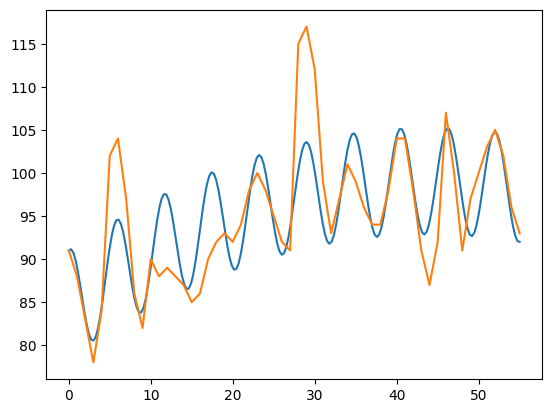

In [49]:
dist_fit = np.linspace(0,55,200)
line_fit = func(dist_fit, *popt)

plt.figure()
plt.plot(dist_fit, line_fit, dist, line)
plt.show()

## Now let's find the frequency of the signal by using phase unwrapping with pre-filtration


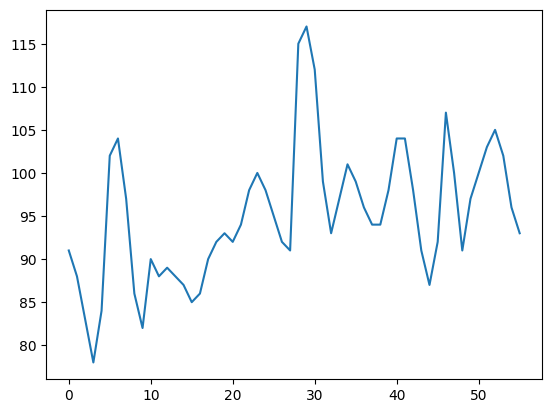

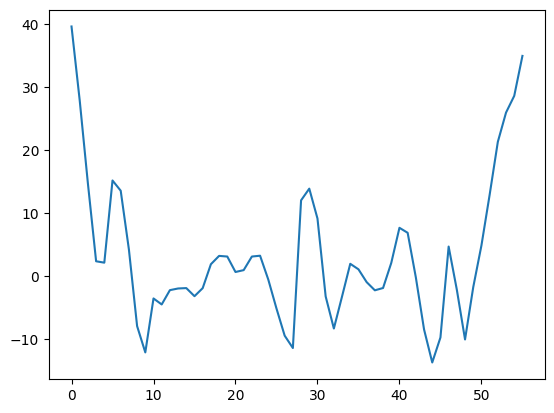

8


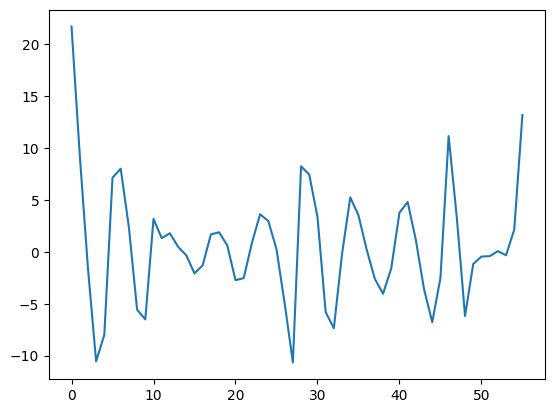

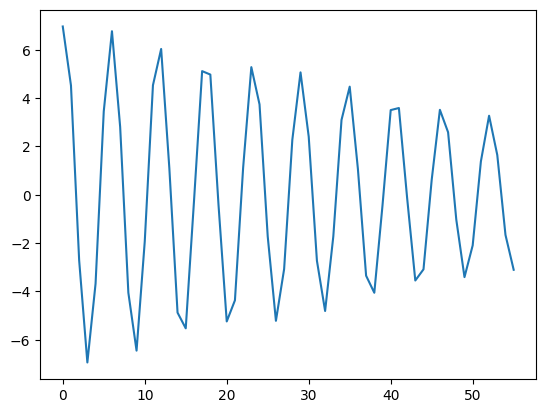

1.0897607487744378


In [67]:
fringe = Fringe(signal = line, fs = 1)
fringe.plot()
fringe.filter_low_frq(nl=3)
fringe.plot()
peak_count = fringe.count_peaks_of_autocorr()
print(peak_count)
fringe.filter_low_frq(nl=peak_count)
fringe.plot()
fringe.update_Wn(rel_h=0.5)
fringe.filter_notch_Wn()
fringe.plot()
frq = fringe.get_frq()
print(frq)

## Testing how selection classes from "generate_areas.py" work

In [3]:
dir_name = 'drop-211025-2'

In [5]:
select = ga.SelectAreas(dir_name)

In [6]:
lp = select.get_line_points()

AttributeError: 'SelectAreas' object has no attribute 'get_line_points'

In [7]:
lines = select.get_lines_from_imgs()

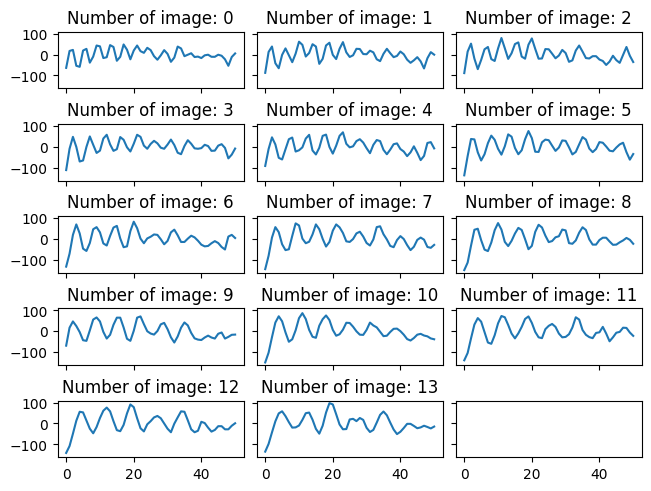

In [8]:
lines.plot()

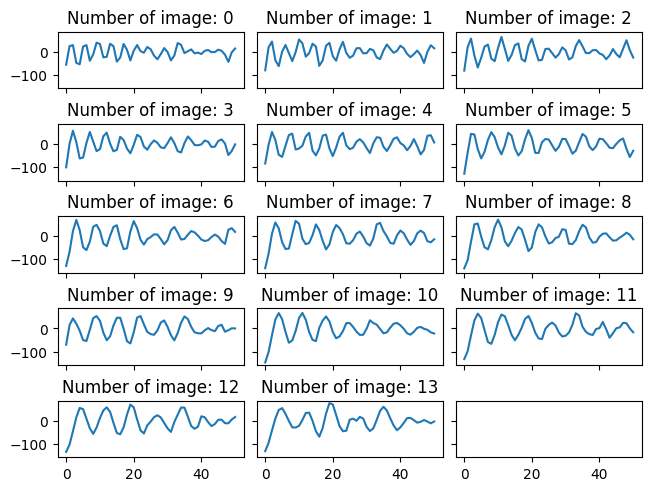

In [9]:
lines_flt = lines.filter_low_frq(inplace=False, nl=2)
lines_flt.plot()

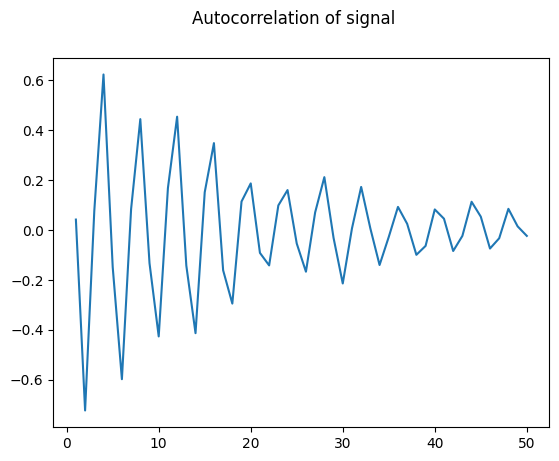

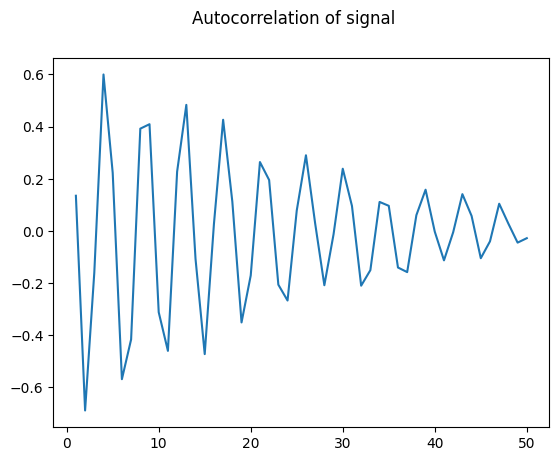

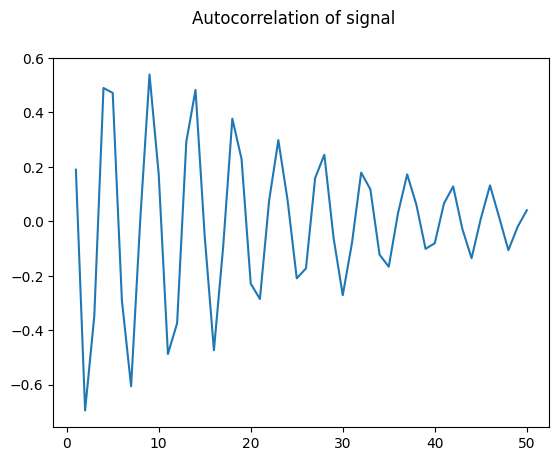

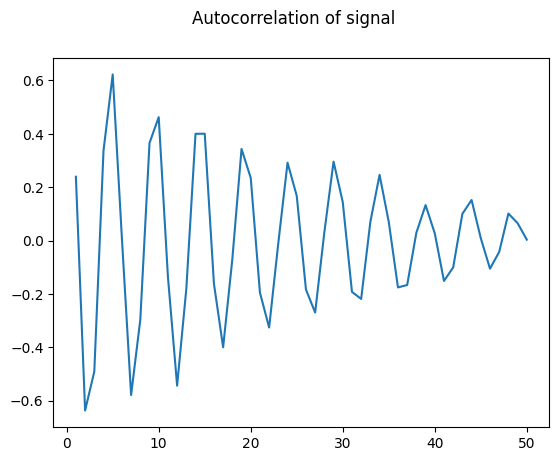

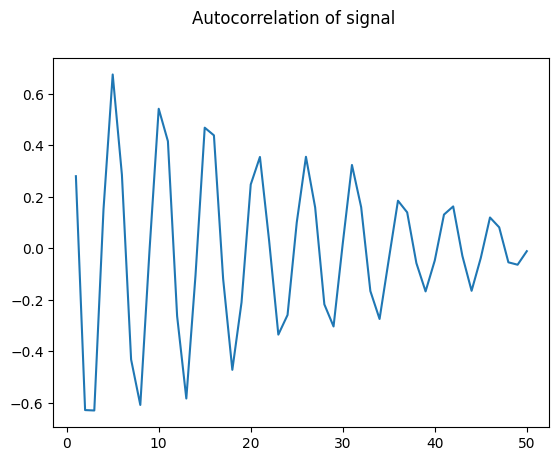

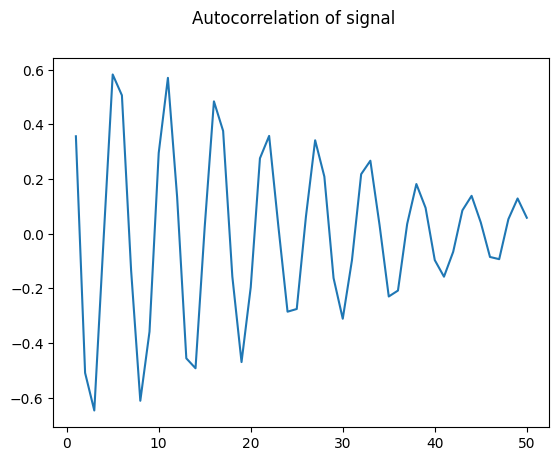

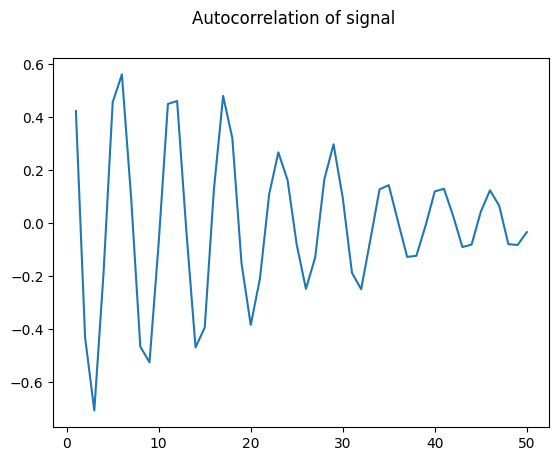

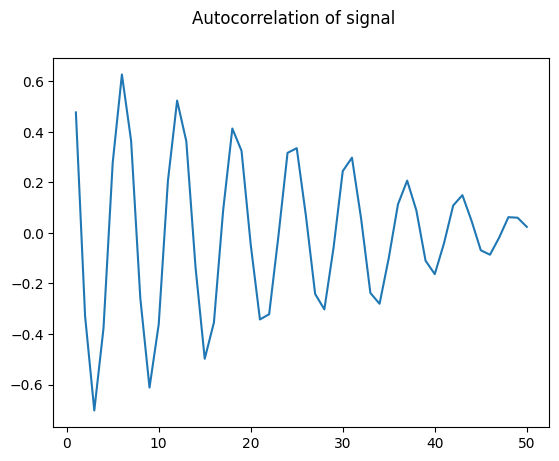

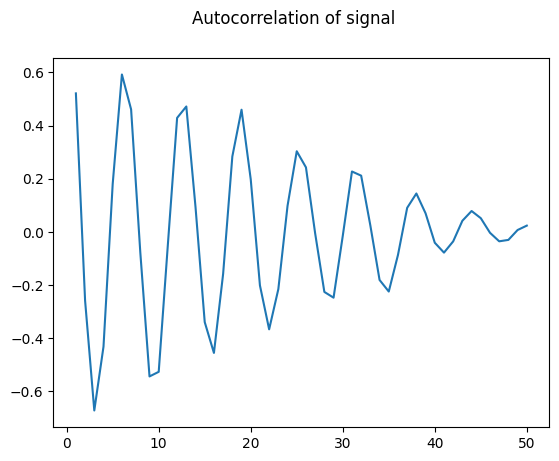

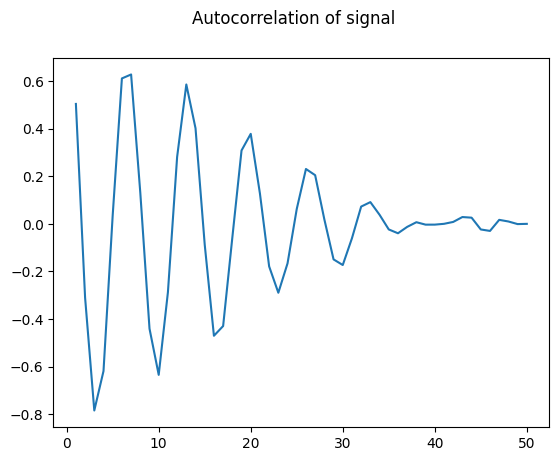

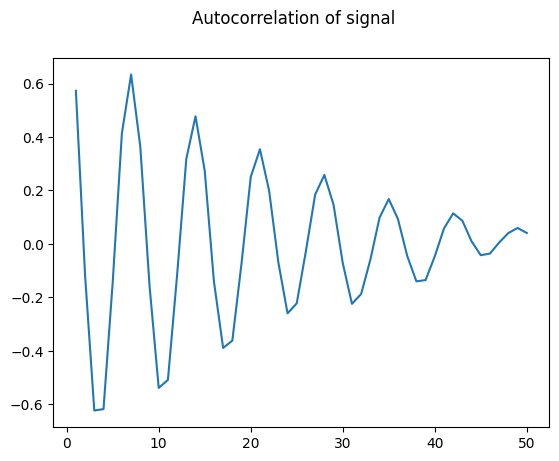

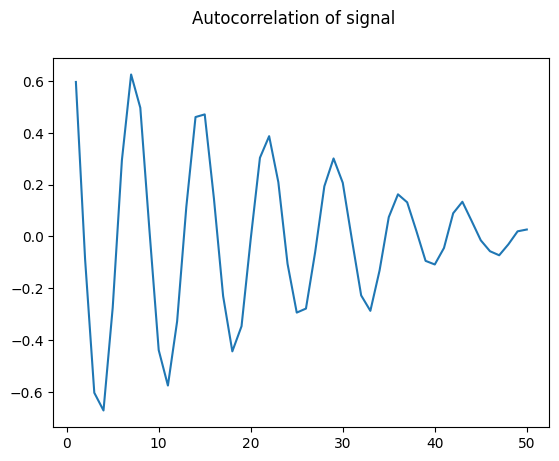

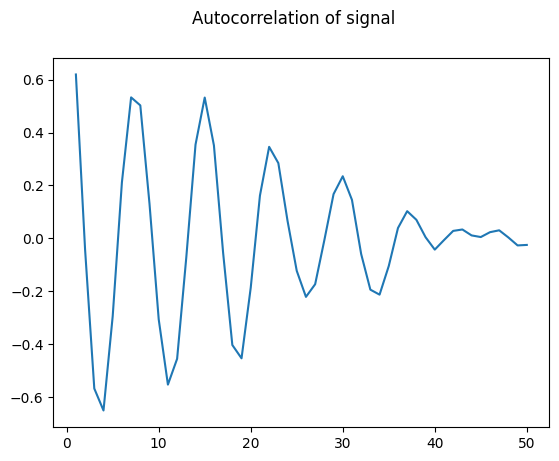

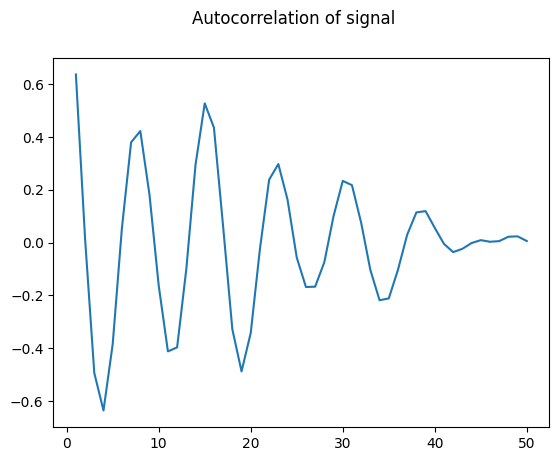

[12, 11, 10, 10, 9, 9, 8, 8, 7, 8, 7, 6, 7, 7]


In [10]:
num_peaks = lines_flt.count_peaks_of_autocorr(show=True)
print(num_peaks)

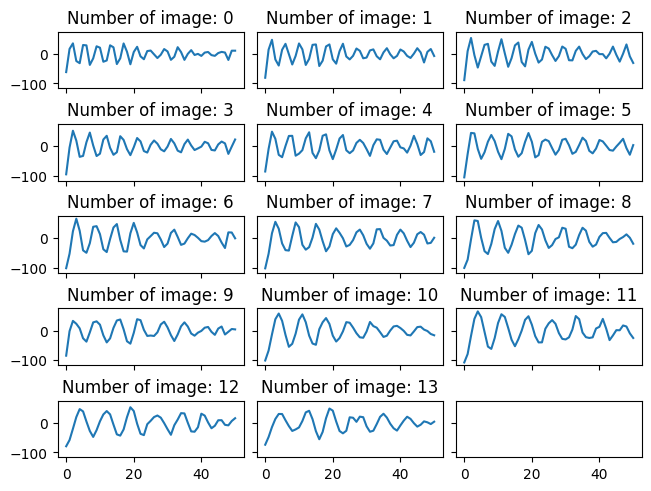

In [11]:
num = [i-1 for i in num_peaks]
lines_flt.filter_low_frq(nl=num)
lines_flt.plot()

[array([0.24249488]), array([0.27325706])]
[array([0.22179254]), array([0.2529687])]
[array([0.20623049]), array([0.23606309])]
[array([0.18960623]), array([0.22970505])]
[array([0.17808377]), array([0.21182299])]
[array([0.1693535]), array([0.20724041])]
[array([0.1610685]), array([0.19240605])]
[array([0.14872031]), array([0.17841307])]
[array([0.14687132]), array([0.17410782])]
[array([0.13768923]), array([0.17172667])]
[array([0.12885181]), array([0.16435985])]
[array([0.1262638]), array([0.15290778])]
[array([0.12306999]), array([0.15220011])]
[array([0.11659325]), array([0.15158472])]


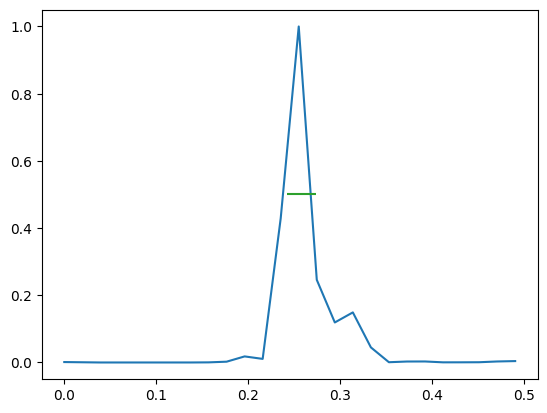

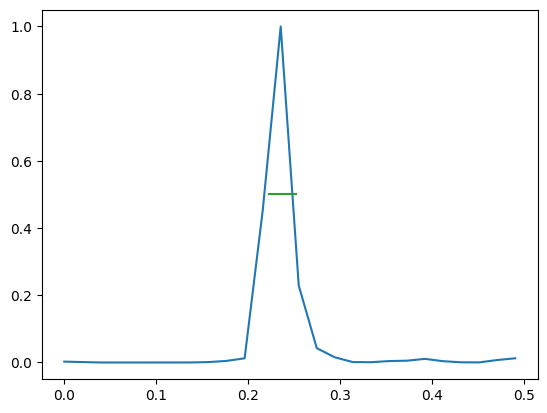

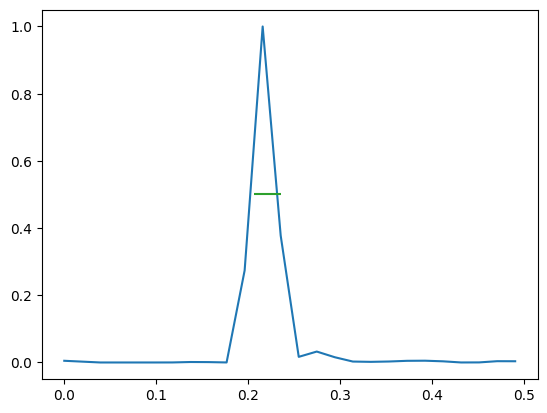

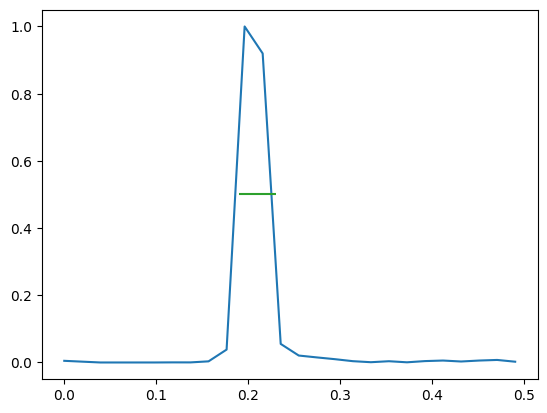

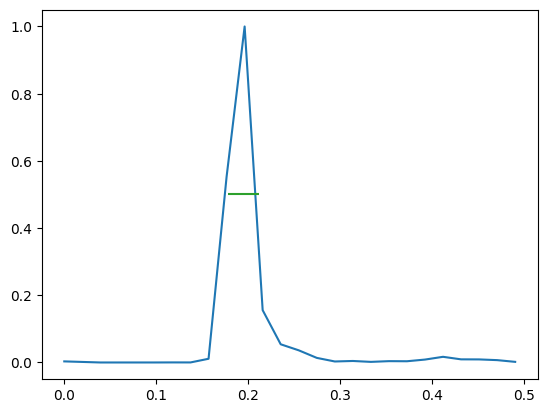

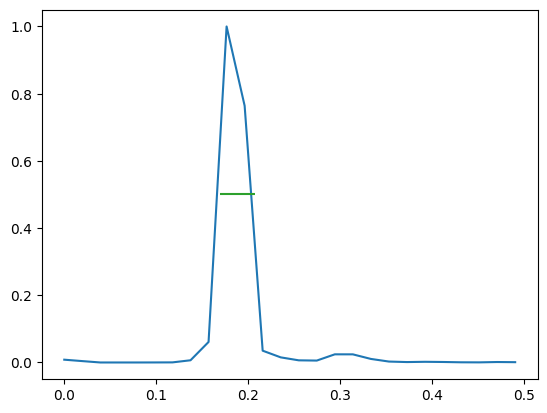

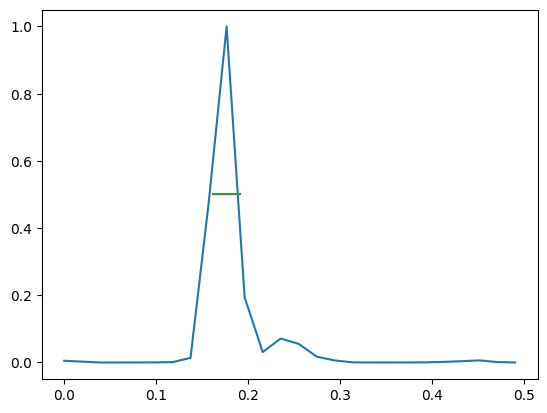

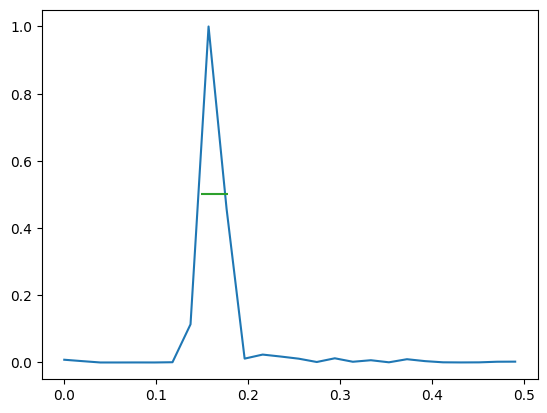

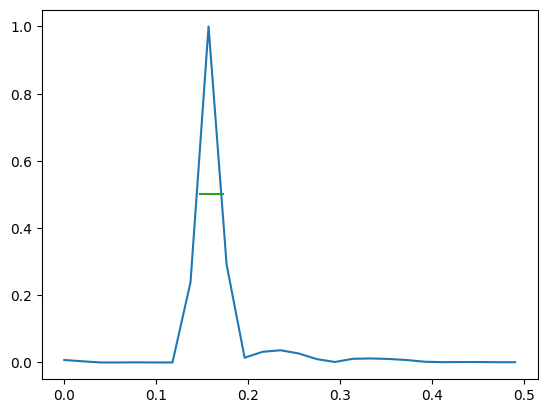

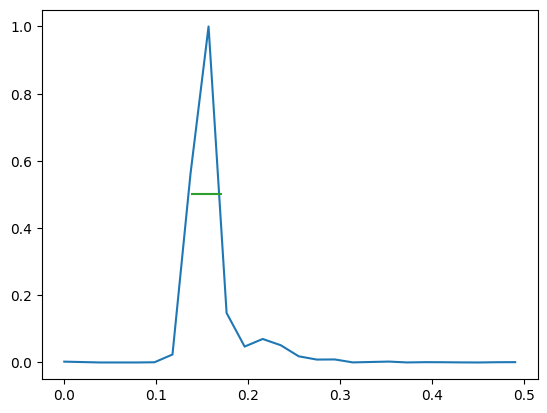

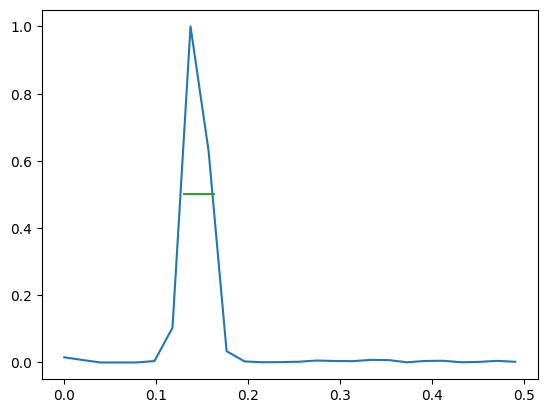

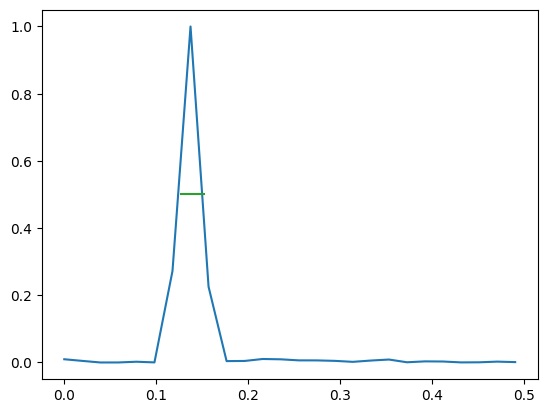

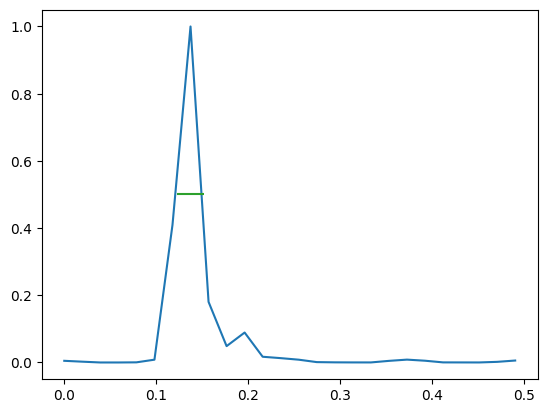

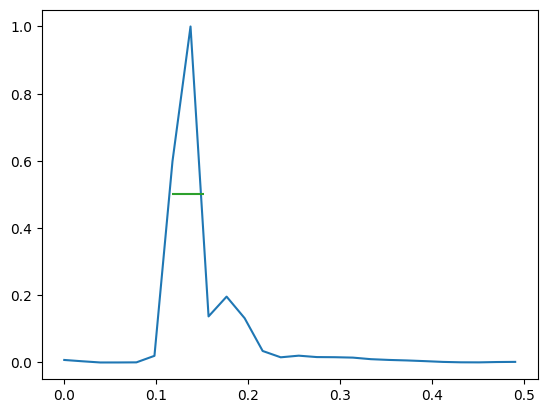

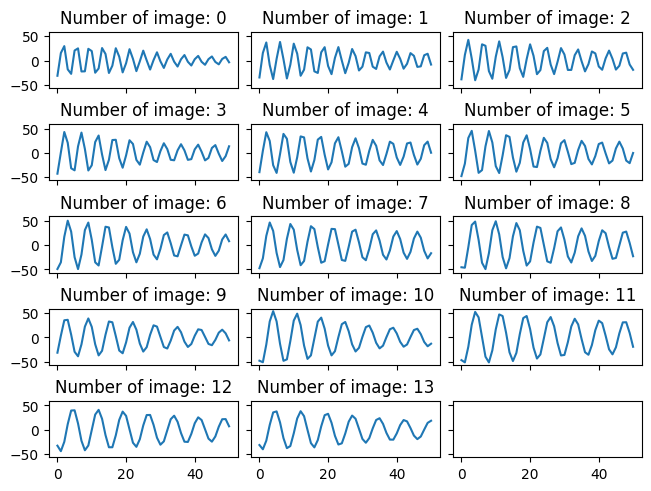

In [12]:
lines_Wn = lines_flt.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
lines_Wn.plot()

In [92]:
lines_flt = lines.filter(inplace=False, rel_h=0.6, nperseg_c=1)
lines_flt.plot()

6
2


ValueError: filter critical frequencies must be greater than 0

In [13]:
init_guess_w = lines_Wn.get_frq(prefilter=False)
lines_flt.get_frq_cos(init_guess_w=init_guess_w)

[np.float64(1.8183571245757968),
 np.float64(1.4639586976041028),
 np.float64(1.363587113868902),
 np.float64(1.2972450600047942),
 np.float64(1.2134663429509946),
 np.float64(1.1548275827055454),
 np.float64(1.0885174081307492),
 np.float64(1.0263916435603206),
 np.float64(0.9915975462582969),
 np.float64(0.9682813589742195),
 np.float64(0.8983771351950043),
 np.float64(0.8642515057987188),
 np.float64(0.8467070895036555),
 np.float64(0.8269494893841295)]

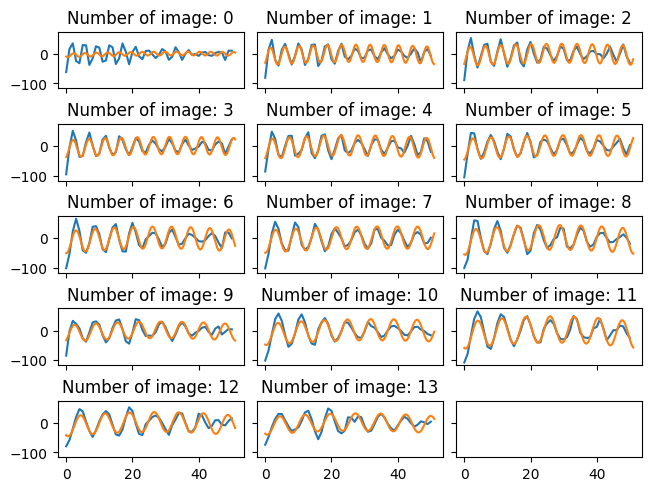

In [14]:
lines_flt.plot(show_cos=True)

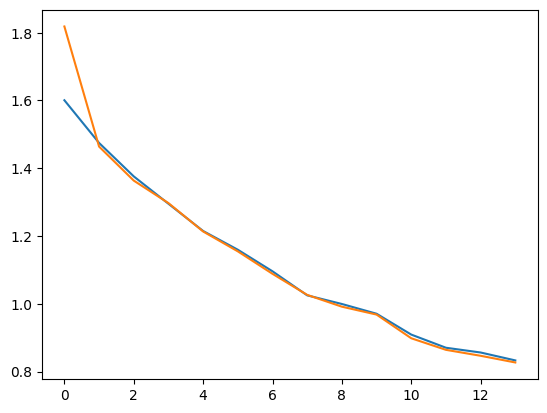

In [15]:
img_number = np.arange(14)

plt.figure()
plt.plot(lines_Wn.frq_list)
plt.plot(lines_flt.frq_cos_list)
plt.show()

In [22]:
a = np.asarray(range(10))
b = np.asarray(range(10,20))

c = np.stack((a,b),axis=1)

print(a)
print(b)
print(c)

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]
[[ 0 10]
 [ 1 11]
 [ 2 12]
 [ 3 13]
 [ 4 14]
 [ 5 15]
 [ 6 16]
 [ 7 17]
 [ 8 18]
 [ 9 19]]
